# Notebook 12 — Thesis Dashboard (Key Evidence in One Place)

Purpose:
- show the most important visual and tabular evidence in presentation order
- summarize what prediction changes versus current reactive flow
- provide quick-slide-ready material for defense

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == 'notebooks' else Path.cwd()
TABLE_DIR = PROJECT_ROOT / 'Results' / 'tables' / 'notebook12_stage_o'
FIG_DIR = PROJECT_ROOT / 'Results' / 'figures' / 'notebook12_stage_o'
REPORT_DIR = PROJECT_ROOT / 'Results' / 'reports' / 'notebook12_stage_o'
for d in [TABLE_DIR, FIG_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Notebook 12 workspace ready')

Notebook 12 workspace ready


In [7]:
# Core KPI snapshot
m_summary_path = PROJECT_ROOT / 'Results' / 'reports' / 'notebook10_stage_m' / 'stage_m_core_validation_summary.txt'
l_summary_path = PROJECT_ROOT / 'Results' / 'reports' / 'notebook09_stage_l' / 'stage_l_clinical_trust_summary.txt'
h_summary_path = PROJECT_ROOT / 'Results' / 'reports' / 'notebook05_stage_h' / 'stage_h_summary.txt'

def read_txt(path):
    if Path(path).exists():
        return Path(path).read_text(encoding='utf-8')
    return ''

kpi_text = {
    'stage_h_summary': read_txt(h_summary_path),
    'stage_l_summary': read_txt(l_summary_path),
    'stage_m_summary': read_txt(m_summary_path)
}

with open(REPORT_DIR / 'stage_o_kpi_snapshot.txt', 'w', encoding='utf-8') as f:
    for k, v in kpi_text.items():
        f.write(f'===== {k} =====\n')
        f.write(v + '\n\n')

print('KPI snapshot compiled')
kpi_df = pd.DataFrame([{'section': k, 'summary_text': v} for k, v in kpi_text.items()])
display(kpi_df)
display(Markdown('### KPI Snapshot (full text)'))
for k, v in kpi_text.items():
    display(Markdown(f'**{k}**'))
    print(v if v else '(missing)')

KPI snapshot compiled


,section,summary_text
0,stage_h_summary,Stage H Baseline Summary\nauroc: 0.999997\npr_...
1,stage_l_summary,Stage L Clinical Trust Summary\nselected_model...
2,stage_m_summary,Stage M Core Validation Summary\npatients: 100...


### KPI Snapshot (full text)

**stage_h_summary**

Stage H Baseline Summary
auroc: 0.999997
pr_auc: 0.999721
brier: 0.004913
ece: 0.007088
n_train: 90000
n_test: 30000



**stage_l_summary**

Stage L Clinical Trust Summary
selected_model_context_from_stage_j: hist_gb_strong
trust_model_used_for_audit: hist_gb_proxy
explain_method: shap_tree
n_eval_rows: 15000
n_failure_cases_cataloged: 0
n_counterfactual_pairs: 120



**stage_m_summary**

Stage M Core Validation Summary
patients: 100000
panel escalation rate: 0.011253
present expected escalations: 1108.480
prediction-adjusted expected escalations: 1025.445
escalations averted: 83.035
admissions avoided: 24.911
bed-days avoided: 161.919
additional case-management hours: 369.600

Interpretation:
- Prediction-adjusted targeting reduces expected escalations under explicit assumptions.
- Benefit concentrates in high/moderate complexity cohorts and depends on cycle-informed intervention timing.
- Operational gain is a trade: more proactive care hours in exchange for fewer downstream admissions.



### Key Figure Checklist

,figure,exists
0,Results/figures/notebook10_stage_m/stage_m_cyc...,True
1,Results/figures/notebook10_stage_m/stage_m_pre...,True
2,Results/figures/notebook10_stage_m/stage_m_cat...,True
3,Results/figures/notebook10_stage_m/stage_m_sen...,True
4,Results/figures/notebook11_stage_n/stage_n_thr...,True
5,Results/figures/notebook11_stage_n/stage_n_dec...,True
6,Results/figures/notebook11_stage_n/stage_n_cyc...,True
7,Results/figures/notebook11_stage_n/stage_n_thr...,True


### Dashboard Contact Sheet

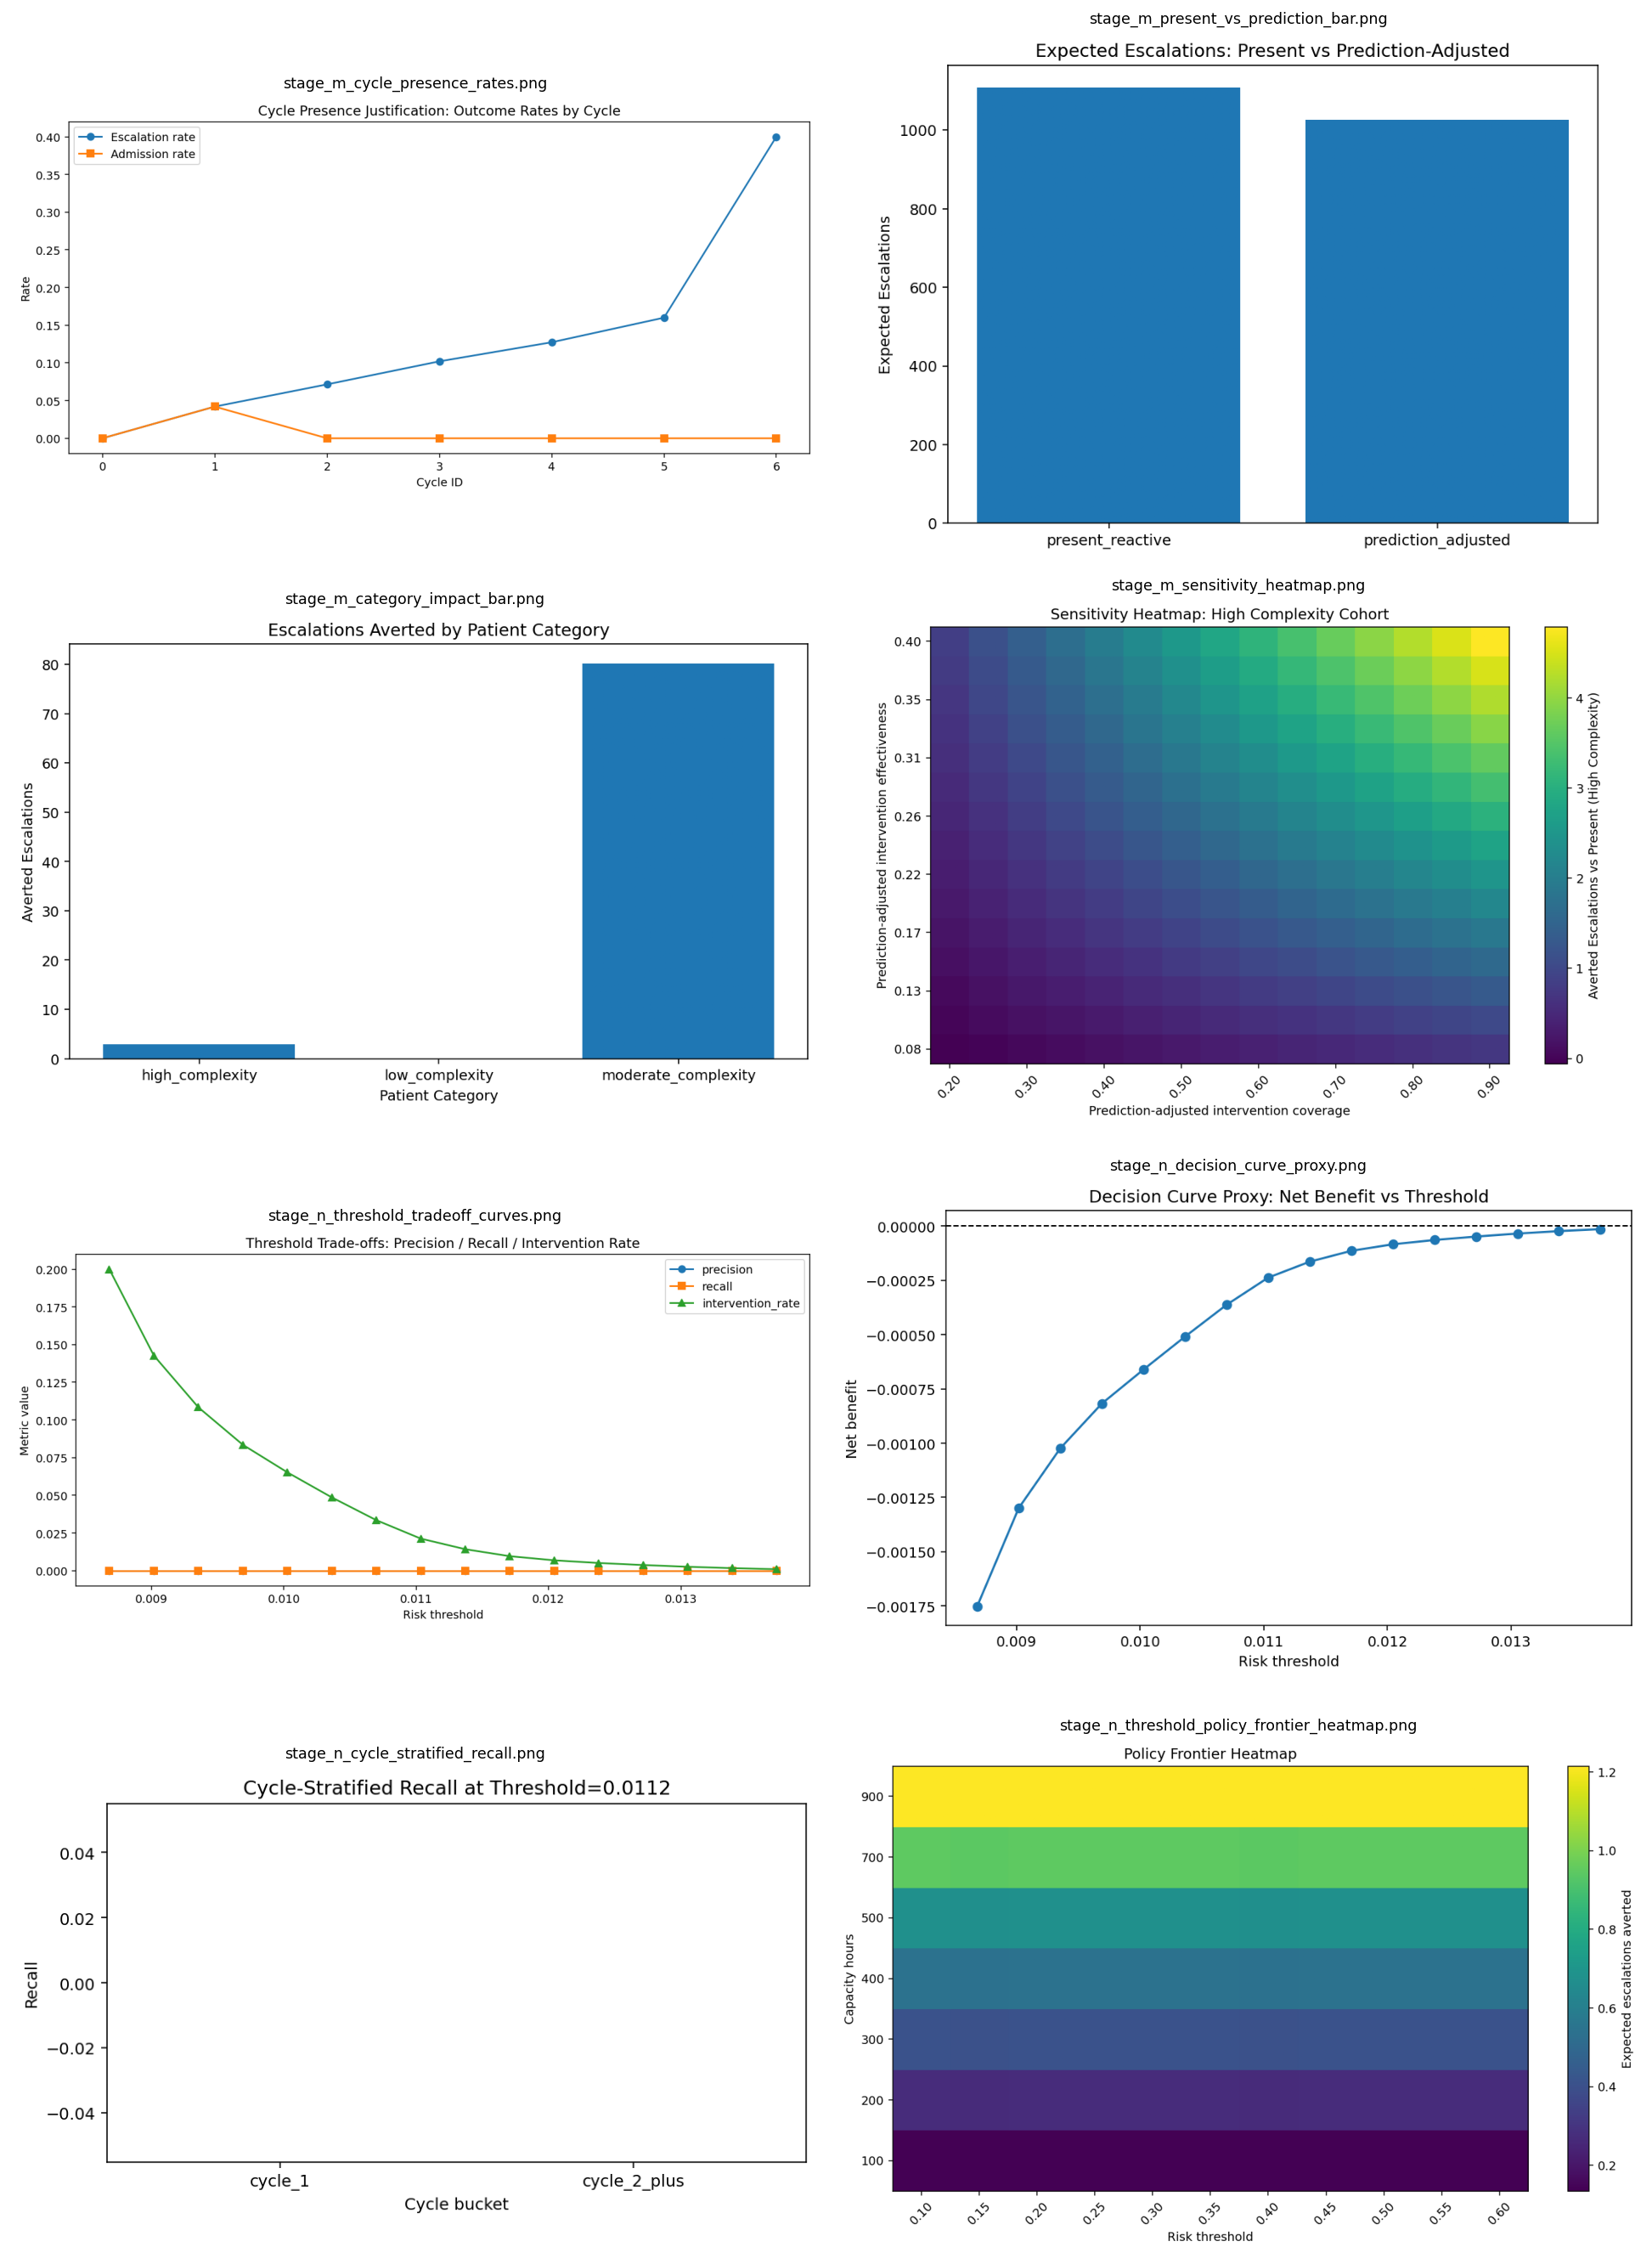

### Individual Figures

**stage_m_cycle_presence_rates.png**

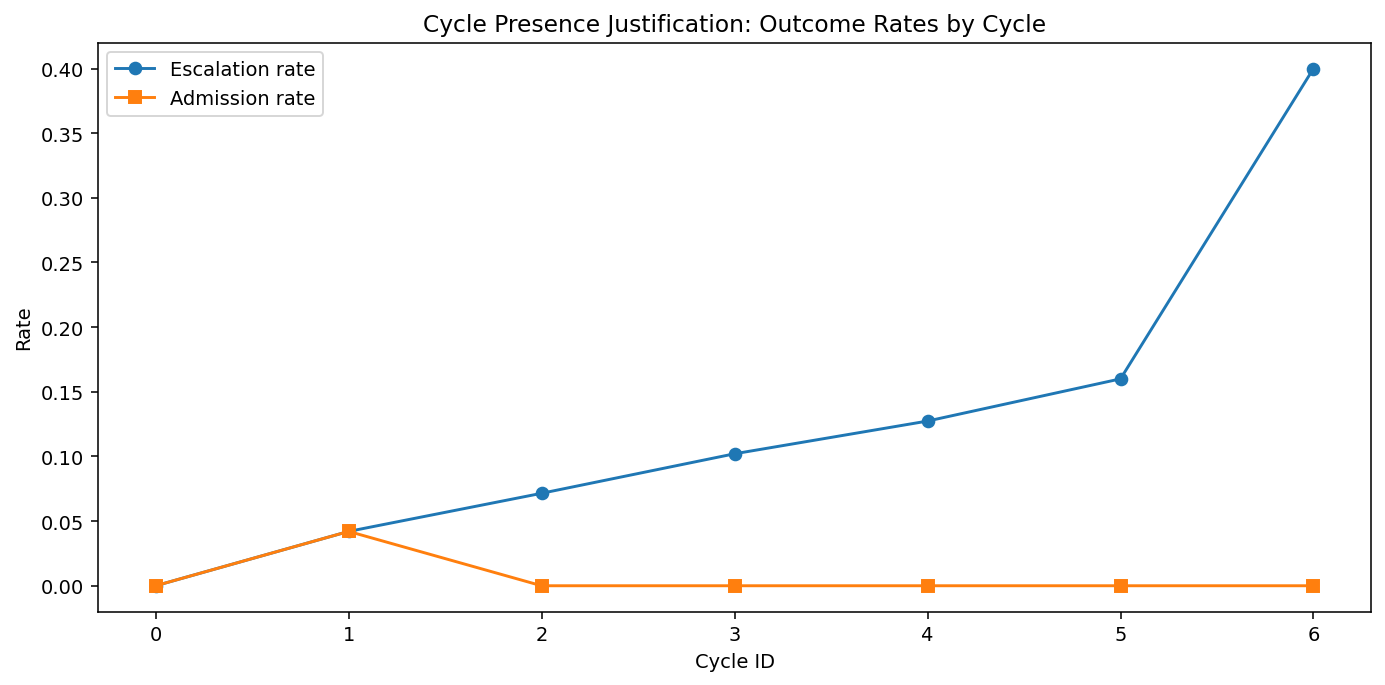

**stage_m_present_vs_prediction_bar.png**

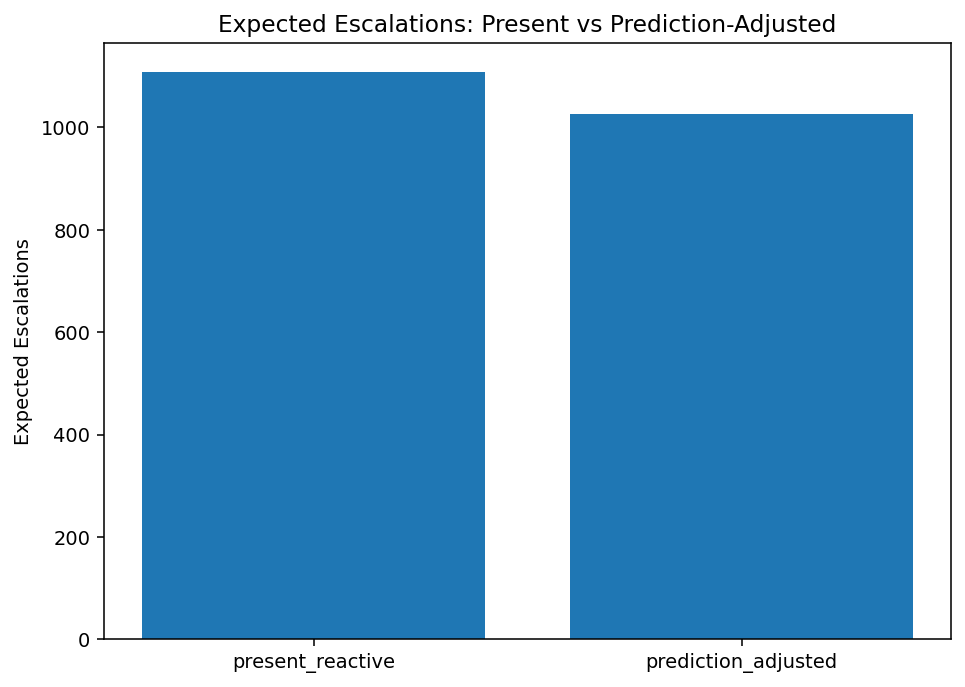

**stage_m_category_impact_bar.png**

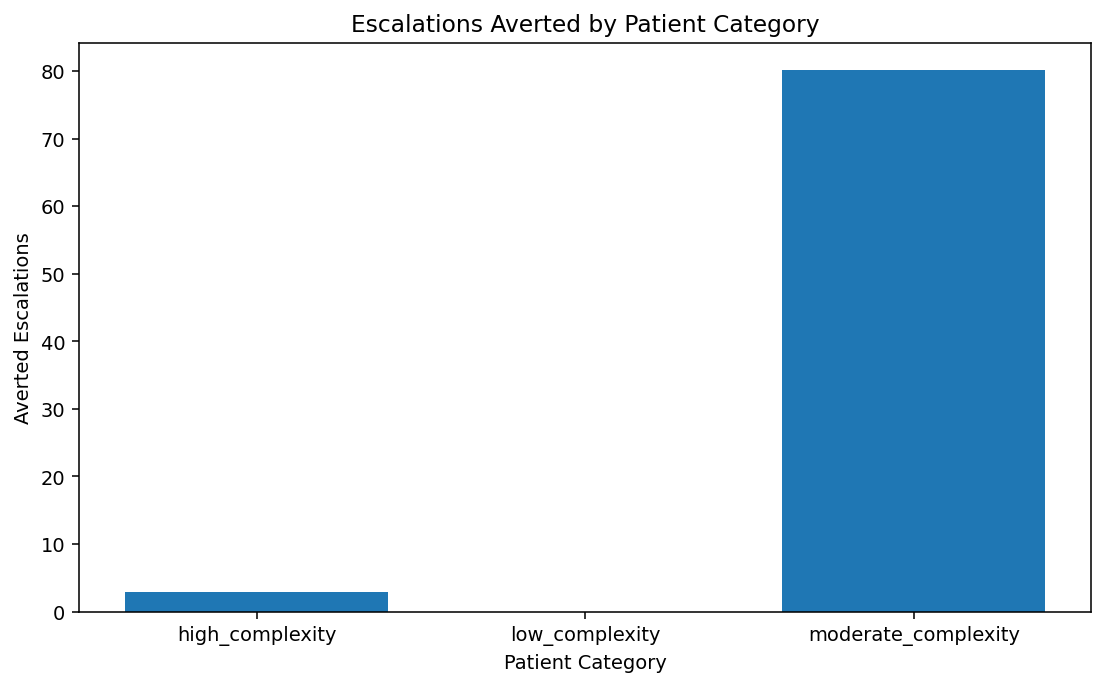

**stage_m_sensitivity_heatmap.png**

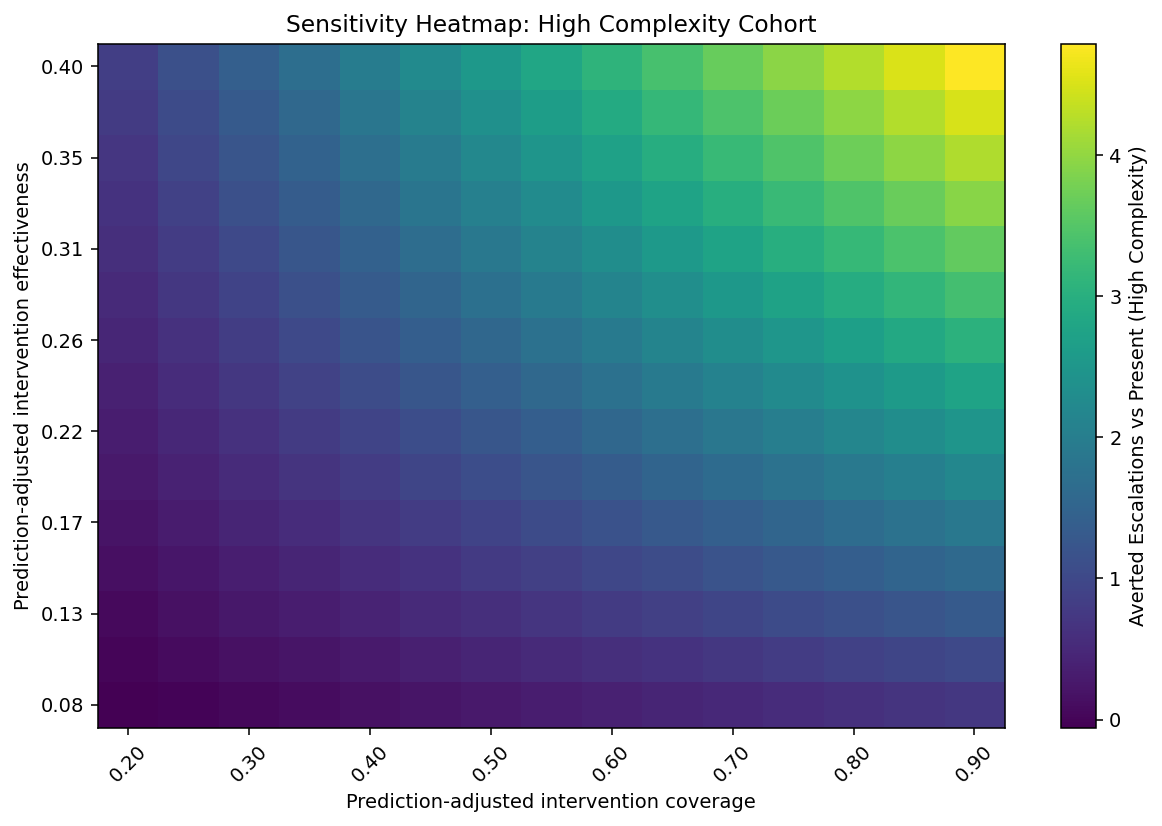

**stage_n_threshold_tradeoff_curves.png**

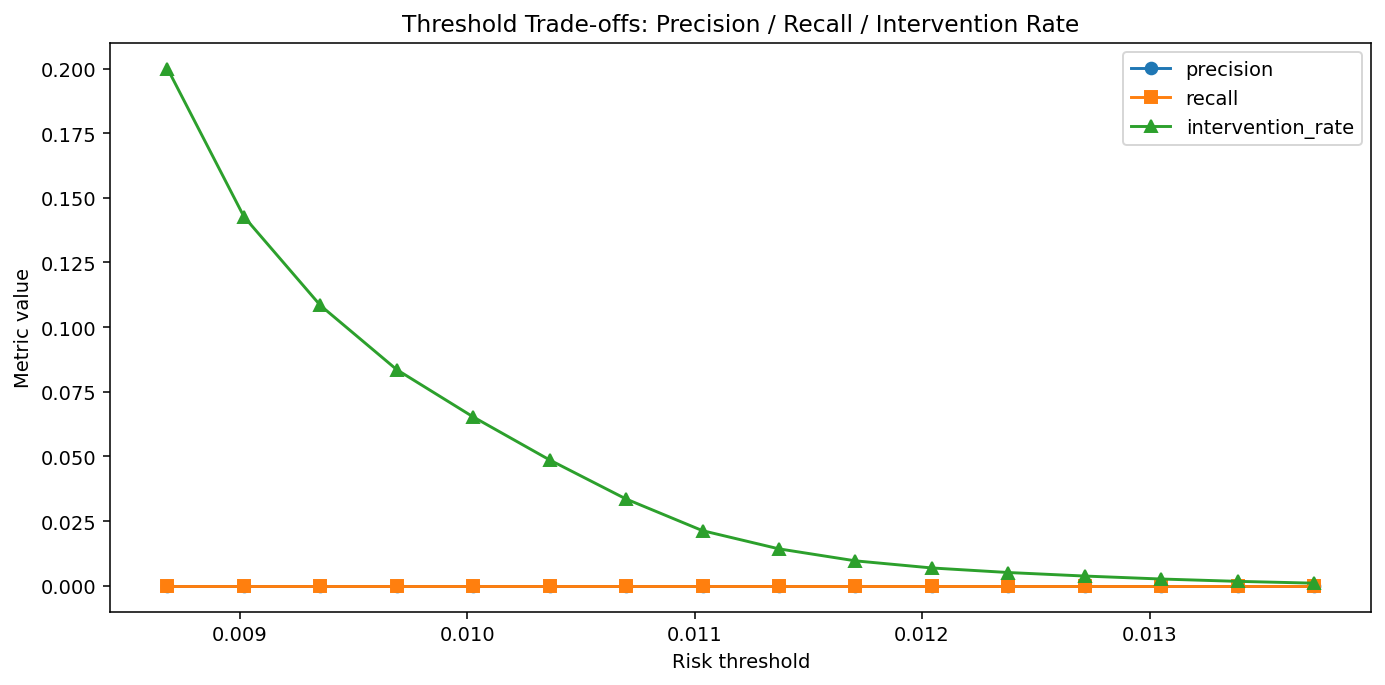

**stage_n_decision_curve_proxy.png**

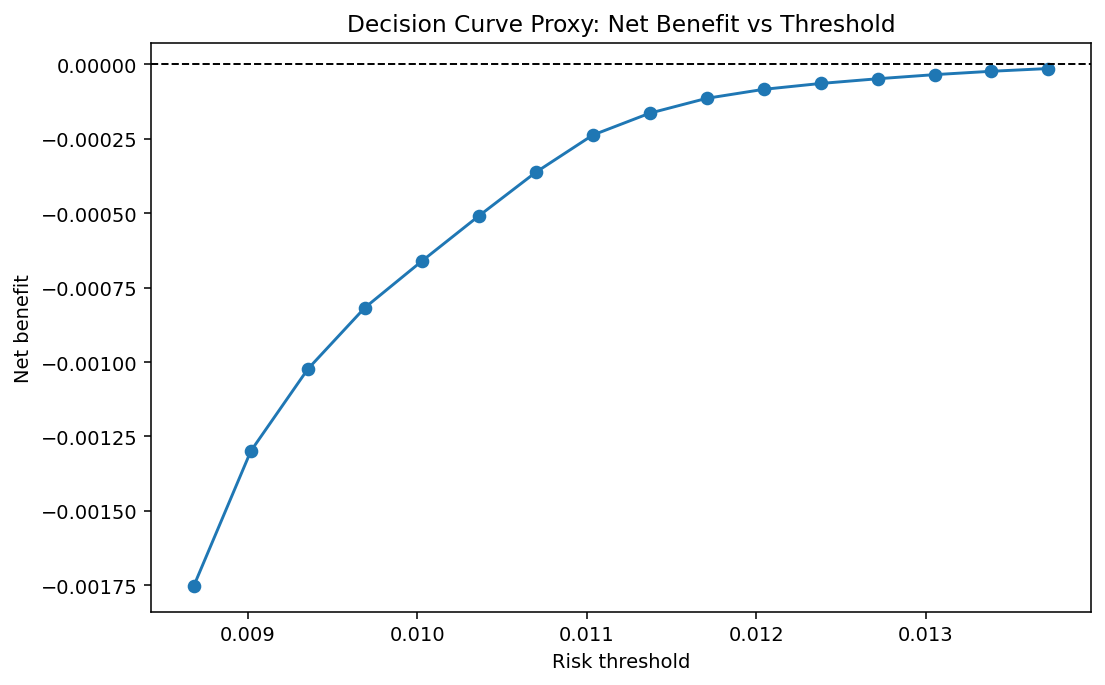

**stage_n_cycle_stratified_recall.png**

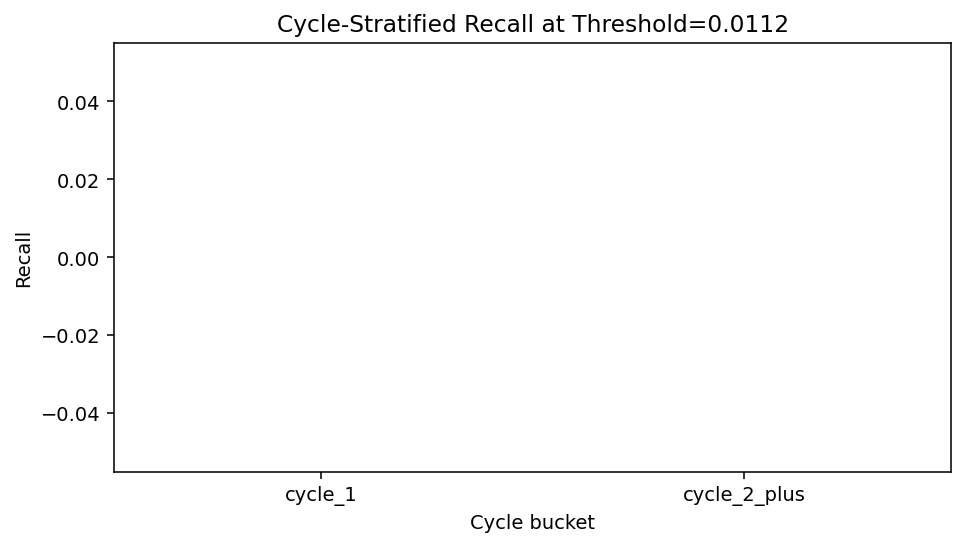

**stage_n_threshold_policy_frontier_heatmap.png**

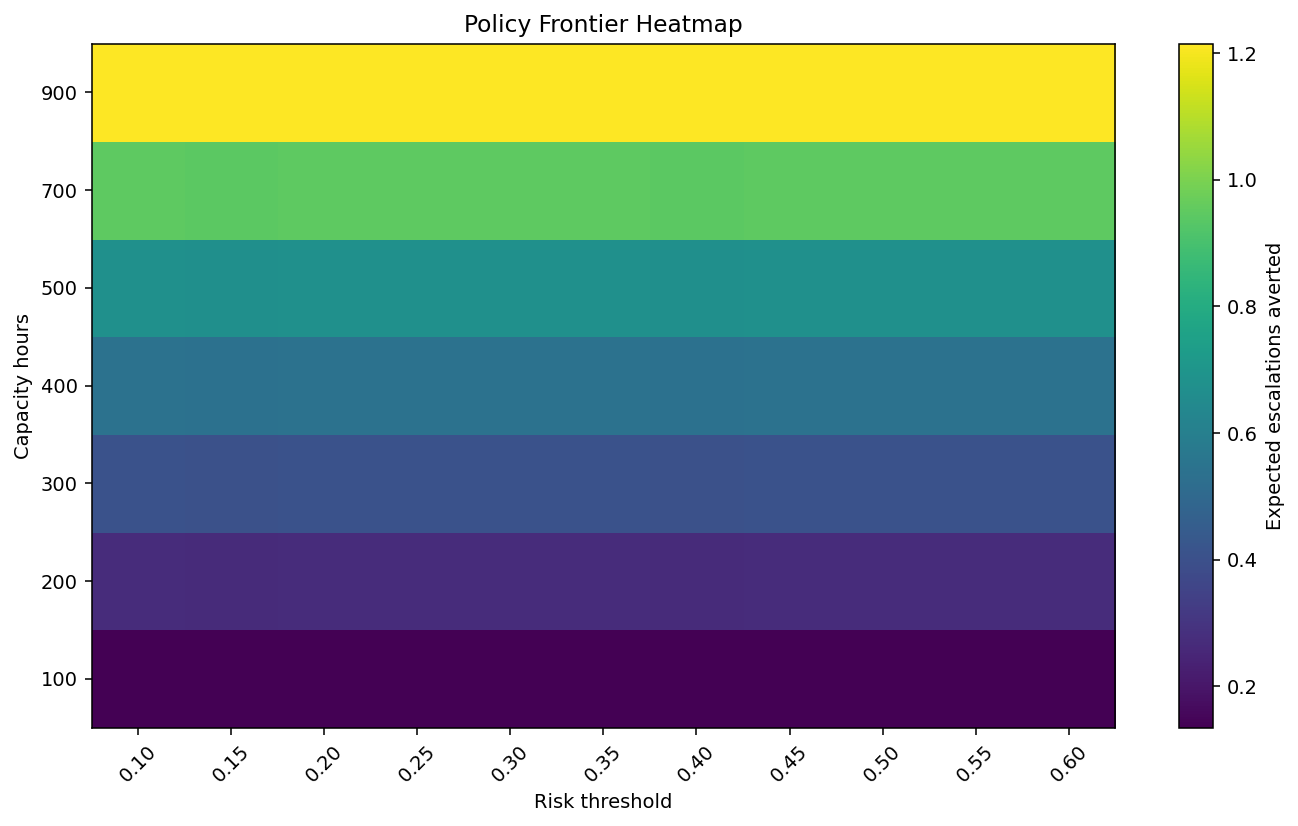

In [8]:
# Display key visuals in thesis order
key_figs = [
    'Results/figures/notebook10_stage_m/stage_m_cycle_presence_rates.png',
    'Results/figures/notebook10_stage_m/stage_m_present_vs_prediction_bar.png',
    'Results/figures/notebook10_stage_m/stage_m_category_impact_bar.png',
    'Results/figures/notebook10_stage_m/stage_m_sensitivity_heatmap.png',
    'Results/figures/notebook11_stage_n/stage_n_threshold_tradeoff_curves.png',
    'Results/figures/notebook11_stage_n/stage_n_decision_curve_proxy.png',
    'Results/figures/notebook11_stage_n/stage_n_cycle_stratified_recall.png',
    'Results/figures/notebook11_stage_n/stage_n_threshold_policy_frontier_heatmap.png'
]

fig_rows = []
for p in key_figs:
    abs_p = PROJECT_ROOT / p
    fig_rows.append({'figure': p, 'exists': abs_p.exists()})

fig_df = pd.DataFrame(fig_rows)
fig_df.to_csv(TABLE_DIR / 'stage_o_key_figure_checklist.csv', index=False)
display(Markdown('### Key Figure Checklist'))
display(fig_df)

n = len(key_figs)
cols = 2
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 4.8 * rows))
axes = np.atleast_1d(axes).ravel()
for i, p in enumerate(key_figs):
    ax = axes[i]
    abs_p = PROJECT_ROOT / p
    if abs_p.exists():
        img = mpimg.imread(abs_p)
        ax.imshow(img)
        ax.set_title(Path(p).name, fontsize=9)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, f'Missing: {Path(p).name}', ha='center', va='center')
        ax.axis('off')
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
dashboard_path = FIG_DIR / 'stage_o_dashboard_key_figures.png'
plt.savefig(dashboard_path, dpi=140, bbox_inches='tight')
plt.close()

display(Markdown('### Dashboard Contact Sheet'))
display(Image(filename=str(dashboard_path)))

display(Markdown('### Individual Figures'))
for p in key_figs:
    abs_p = PROJECT_ROOT / p
    display(Markdown(f'**{Path(p).name}**'))
    if abs_p.exists():
        display(Image(filename=str(abs_p)))
    else:
        print(f'Missing: {abs_p}')

In [9]:
# Consolidated evidence table
paths = {
    'stage_h_perf': PROJECT_ROOT / 'Results' / 'tables' / 'notebook05_stage_h' / 'stage_h_baseline_model_performance.csv',
    'stage_l_model_metrics': PROJECT_ROOT / 'Results' / 'tables' / 'notebook09_stage_l' / 'stage_l_model_metrics.csv',
    'stage_m_resource': PROJECT_ROOT / 'Results' / 'tables' / 'notebook10_stage_m' / 'stage_m_resource_translation.csv',
    'stage_n_top_policy': PROJECT_ROOT / 'Results' / 'tables' / 'notebook11_stage_n' / 'stage_n_policy_top_configs.csv'
}

source_tables = {}
for name, p in paths.items():
    if p.exists():
        source_tables[name] = pd.read_csv(p)
    else:
        source_tables[name] = None

display(Markdown('### Source Tables Used in Stage O'))
for name, df_src in source_tables.items():
    display(Markdown(f'**{name}**'))
    if df_src is None:
        print(f'Missing: {paths[name]}')
    else:
        display(df_src.head(20))

evidence = []
df = source_tables['stage_h_perf']
if df is not None and len(df):
    evidence.append({'source': 'Stage H', 'key': 'AUROC baseline', 'value': float(df['auroc'].iloc[0])})
    evidence.append({'source': 'Stage H', 'key': 'ECE baseline', 'value': float(df['ece'].iloc[0])})
df = source_tables['stage_l_model_metrics']
if df is not None and len(df):
    for _, r in df.iterrows():
        evidence.append({'source': 'Stage L', 'key': f"AUROC {r['model']}", 'value': float(r['auroc'])})
df = source_tables['stage_m_resource']
if df is not None and len(df):
    for k in ['escalations_averted', 'admissions_avoided', 'bed_days_avoided', 'additional_case_management_hours']:
        val = df.loc[df['metric'] == k, 'value']
        if len(val):
            evidence.append({'source': 'Stage M', 'key': k, 'value': float(val.iloc[0])})
df = source_tables['stage_n_top_policy']
if df is not None and len(df):
    evidence.append({'source': 'Stage N', 'key': 'top_threshold', 'value': float(df['risk_threshold'].iloc[0])})
    evidence.append({'source': 'Stage N', 'key': 'top_capacity_hours', 'value': float(df['capacity_hours'].iloc[0])})
    evidence.append({'source': 'Stage N', 'key': 'top_expected_escalations_averted', 'value': float(df['expected_escalations_averted'].iloc[0])})

evidence_df = pd.DataFrame(evidence)
evidence_df.to_csv(TABLE_DIR / 'stage_o_consolidated_evidence_table.csv', index=False)
display(Markdown('### Consolidated Evidence Table'))
display(evidence_df)

### Source Tables Used in Stage O

**stage_h_perf**

,model,auroc,pr_auc,brier,ece,n_test
0,logistic_baseline_stage_h,0.999997,0.999721,0.004913,0.007088,30000


**stage_l_model_metrics**

,model,auroc,pr_auc,brier,log_loss
0,logistic_intrinsic,0.999942,0.997365,5.226191e-03,1.475882e-02
1,hist_gb_proxy,1.000000,1.000000,6.791150e-13,1.516075e-07


...

,metric,value
0,expected_escalations_present,1108.479948
1,expected_escalations_prediction_adjusted,1025.444694
2,escalations_averted,83.035254
3,expected_admissions_present,332.543984
4,expected_admissions_prediction_adjusted,307.633408
5,admissions_avoided,24.910576
6,bed_days_avoided,161.918744
7,additional_case_management_hours,369.600000


**stage_n_top_policy**

,risk_threshold,capacity_hours,patients_covered,expected_escalations_averted,hours_utilization_fraction
0,0.10,900.0,521.460449,1.215265,0.010944
1,0.45,900.0,521.460449,1.215265,0.030097
2,0.60,900.0,521.460449,1.215265,0.120387
3,0.35,900.0,521.460449,1.215265,0.020064
4,0.20,900.0,521.460449,1.215265,0.013376
5,0.55,900.0,521.460449,1.215265,0.060193
6,0.50,900.0,521.460449,1.215265,0.040129
7,0.25,900.0,521.460449,1.215265,0.015048
8,0.30,900.0,521.460449,1.215265,0.017198
9,0.40,900.0,521.460449,1.215265,0.024077


### Consolidated Evidence Table

,source,key,value
0,Stage H,AUROC baseline,0.999997
1,Stage H,ECE baseline,0.007088
2,Stage L,AUROC logistic_intrinsic,0.999942
3,Stage L,AUROC hist_gb_proxy,1.000000
4,Stage M,escalations_averted,83.035254
5,Stage M,admissions_avoided,24.910576
6,Stage M,bed_days_avoided,161.918744
7,Stage M,additional_case_management_hours,369.600000
8,Stage N,top_threshold,0.100000
9,Stage N,top_capacity_hours,900.000000


In [10]:
# Short defense narrative scaffold
narrative = [
    '1) Cycle presence is visible and quantifiable (Stage M cycle plots).',
    '2) Prediction-adjusted strategy reduces expected escalation burden versus present reactive flow.',
    '3) Reduction translates into fewer expected admissions and bed-days with explicit resource trade-offs.',
    '4) Threshold frontier and decision-curve diagnostics show policy sensitivity to capacity and threshold choice.',
    '5) Medication recommendations are now registry-backed with explicit labels/classes.'
]
with open(REPORT_DIR / 'stage_o_defense_narrative.txt', 'w', encoding='utf-8') as f:
    f.write('Stage O Defense Narrative\n')
    for line in narrative:
        f.write(f'- {line}\n')

print('Stage O narrative generated')
pd.DataFrame({'narrative': narrative})

Stage O narrative generated


,narrative
0,1) Cycle presence is visible and quantifiable ...
1,2) Prediction-adjusted strategy reduces expect...
2,3) Reduction translates into fewer expected ad...
3,4) Threshold frontier and decision-curve diagn...
4,5) Medication recommendations are now registry...


In [ ]:
# Inline artifact gallery for this notebook stage
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = PROJECT_ROOT if 'PROJECT_ROOT' in globals() else (Path.cwd().parent if Path.cwd().name.lower() == 'notebooks' else Path.cwd())
STAGE_PREFIX = 'notebook12'

def _match_stage_dirs(base, prefix):
    if not base.exists():
        return []
    return sorted([p for p in base.glob(f'{prefix}*') if p.is_dir()])

def _show_table_file(path):
    suffix = path.suffix.lower()
    display(Markdown(f'**{path.name}**'))
    try:
        if suffix == '.csv':
            display(pd.read_csv(path).head(200))
        elif suffix == '.parquet':
            display(pd.read_parquet(path).head(200))
        elif suffix == '.json':
            data = json.loads(path.read_text(encoding='utf-8'))
            if isinstance(data, list):
                display(pd.DataFrame(data).head(200))
            elif isinstance(data, dict):
                display(pd.DataFrame([data]).T.head(200))
            else:
                print(str(data)[:12000])
        elif suffix in {'.txt', '.md'}:
            print(path.read_text(encoding='utf-8')[:12000])
    except Exception as exc:
        print(f'Could not render {path.name}: {exc}')

table_dirs = _match_stage_dirs(ROOT / 'Results' / 'tables', STAGE_PREFIX)
figure_dirs = _match_stage_dirs(ROOT / 'Results' / 'figures', STAGE_PREFIX)
report_dirs = _match_stage_dirs(ROOT / 'Results' / 'reports', STAGE_PREFIX)

display(Markdown(f'## Inline Artifact Gallery: {STAGE_PREFIX}'))
if not table_dirs and not figure_dirs and not report_dirs:
    print('No stage-matched artifact folders found yet. Run generation cells first.')

for d in table_dirs:
    display(Markdown(f'### Tables ({d.name})'))
    files = sorted([p for p in d.iterdir() if p.is_file() and p.suffix.lower() in {'.csv', '.parquet', '.json', '.txt'}])
    if not files:
        print('No table files found')
    for fp in files:
        _show_table_file(fp)

for d in figure_dirs:
    display(Markdown(f'### Visualizations ({d.name})'))
    imgs = sorted([p for p in d.iterdir() if p.is_file() and p.suffix.lower() in {'.png', '.jpg', '.jpeg'}])
    if not imgs:
        print('No figure files found')
    for fp in imgs:
        display(Markdown(f'**{fp.name}**'))
        display(Image(filename=str(fp)))

for d in report_dirs:
    display(Markdown(f'### Reports ({d.name})'))
    files = sorted([p for p in d.iterdir() if p.is_file() and p.suffix.lower() in {'.csv', '.json', '.txt', '.md'}])
    if not files:
        print('No report files found')
    for fp in files:
        _show_table_file(fp)